In [1]:
import pandas as pd
import os 
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import ipywidgets as widgets
widgets.IntSlider()
%matplotlib widget

In [3]:
DADOS = "../dados/Mall_Customers_no_CustomerID.csv"

df = pd.read_csv(DADOS)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessing = ColumnTransformer(
    [
        ("standard", StandardScaler(), ["Age", "Annual Income (k$)", "Spending Score (1-100)"]),
        ("onehot", OneHotEncoder(), ["Gender"])    
    ]
)

preprocessing.fit_transform(df)

df_scaled = pd.DataFrame(
    preprocessing.fit_transform(df),
    columns=preprocessing.get_feature_names_out(),
)

df_scaled.head()

,standard__Age,standard__Annual Income (k$),standard__Spending Score (1-100),onehot__Gender_Female,onehot__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


### Pré-processamento dos Dados
Antes da aplicação de algoritmos de Machine Learning, foi realizado o pré-processamento dos dados com o objetivo de padronizar variáveis numéricas e codificar variáveis categóricas, garantindo que todas as features estejam em um formato adequado para os modelos.

### Padronização das Variáveis Numéricas
As variáveis numéricas Age, Annual Income (k$) e Spending Score (1-100) foram padronizadas utilizando o StandardScaler, que transforma os dados para uma distribuição com:
- média igual a 0
- desvio padrão igual a 1

### Codificação da Variável Categórica
A variável categórica Gender foi transformada utilizando One-Hot Encoding, convertendo as categorias em colunas binárias:
- onehot_Gender_Female
- onehot_Gender_Male

Essa abordagem evita a criação de uma relação ordinal inexistente entre as categorias.

In [6]:
df_scaled.to_csv("../dados/Mall_Customers_no_CustomerID_scaled.csv", index=False)

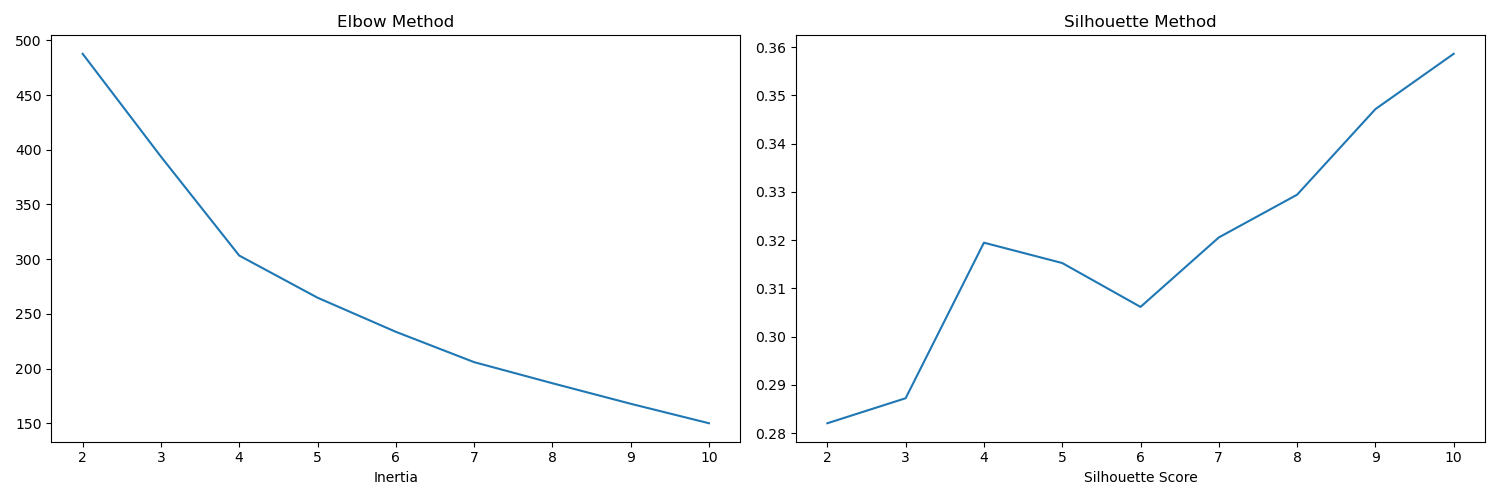

In [10]:
import importlib
import funcoes_auxiliares
importlib.reload(funcoes_auxiliares)

from funcoes_auxiliares import graficos_elbow_silhouette

graficos_elbow_silhouette(df_scaled)

### Definição do Número Ideal de Clusters
Para definir o número ideal de clusters no algoritmo K-Means, foram utilizados dois métodos amplamente adotados: Elbow Method e Silhouette Method. Ambos foram aplicados sobre o dataset já pré-processado e padronizado.

#### Elbow Method
- Há uma queda acentuada da inércia entre k = 2 e k = 4.
- A partir de k = 5, a redução da inércia passa a ser mais gradual. O ponto de inflexão (“cotovelo”) ocorre aproximadamente em k = 4 ou k = 5.

#### Silhouette Method
O Silhouette Method mede o quão bem cada ponto está alocado dentro do seu cluster, variando de -1 a 1, onde valores mais altos indicam melhor separação.
- O Silhouette Score apresenta um bom valor em k = 4.
- Há uma queda em k = 5 e k = 6, seguida de crescimento para valores maiores de k.
- Apesar de valores mais altos em k maiores, isso pode indicar over-segmentation, com clusters excessivamente específicos.

O valor de k = 5 representa um equilíbrio entre separação dos clusters e interpretabilidade, sendo adequado para segmentação de clientes.

##### Escolha Final
Com base na análise conjunta dos dois métodos:
- Elbow Method sugere k entre 4 e 5
- Silhouette Method apresenta bom desempenho nessa mesma faixa


In [6]:
from sklearn.cluster import KMeans

pipeline = Pipeline(
    [
        ("preprocessing", preprocessing), 
        ("clustering", KMeans(n_clusters=5, random_state=42, n_init=10))
    ]
)

pipeline.fit(df)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standard', StandardScaler(),
                                                  ['Age', 'Annual Income (k$)',
                                                   'Spending Score (1-100)']),
                                                 ('onehot', OneHotEncoder(),
                                                  ['Gender'])])),
                ('clustering',
                 KMeans(n_clusters=5, n_init=10, random_state=42))])

### Pipeline de Clusterização com K-Means
Nesta etapa, foi construído um Pipeline de Machine Learning utilizando o Pipeline do scikit-learn, integrando o pré-processamento dos dados e o algoritmo de clusterização K-Means em um único fluxo.



In [7]:
pipeline["clustering"].labels_

array([4, 2, 4, 2, 4, 2, 4, 2, 1, 2, 1, 2, 1, 2, 4, 2, 4, 2, 1, 2, 4, 2,
       1, 2, 1, 2, 1, 2, 4, 2, 1, 2, 1, 2, 1, 2, 1, 2, 4, 2, 1, 2, 1, 4,
       1, 2, 1, 4, 4, 4, 1, 4, 4, 1, 1, 1, 1, 1, 4, 1, 1, 4, 1, 1, 1, 4,
       1, 1, 4, 4, 1, 1, 1, 1, 1, 4, 1, 4, 4, 1, 1, 4, 1, 1, 4, 1, 1, 4,
       4, 1, 1, 4, 1, 4, 4, 4, 1, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 1, 1,
       1, 4, 4, 4, 4, 4, 1, 1, 1, 1, 4, 4, 4, 0, 4, 0, 3, 0, 3, 0, 3, 0,
       4, 0, 3, 0, 3, 0, 3, 0, 3, 0, 4, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 1, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0], dtype=int32)

In [8]:
df_clustered = df.copy()
df_clustered["cluster"] = pipeline["clustering"].labels_

df_clustered.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


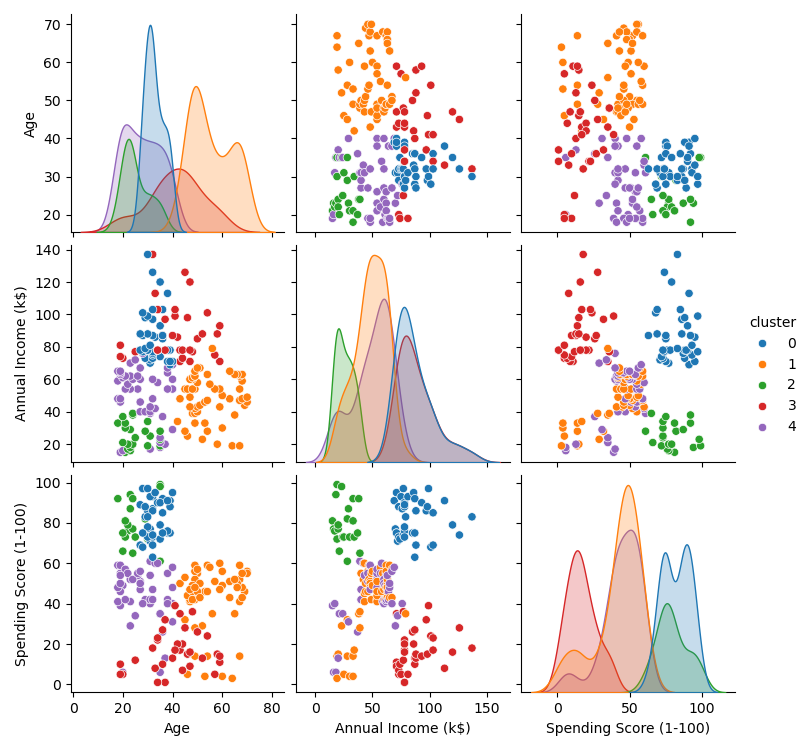

In [9]:
import seaborn as sns 

sns.pairplot(df_clustered, diag_kind="kde", hue="cluster", palette="tab10");

### Visualização e Interpretação dos Clusters
A figura acima apresenta um pairplot das variáveis Age, Annual Income (k$) e Spending Score (1-100), colorido de acordo com os 5 clusters identificados pelo algoritmo K-Means.

#### Análise Geral
- O Spending Score é a variável que melhor separa os clusters.
- A Renda Anual complementa a segmentação, especialmente entre clientes de alto e médio valor.
- A Idade atua como variável auxiliar na diferenciação dos perfis.
- Os clusters apresentam boa separação, indicando que o valor de k = 5 foi uma escolha adequada.

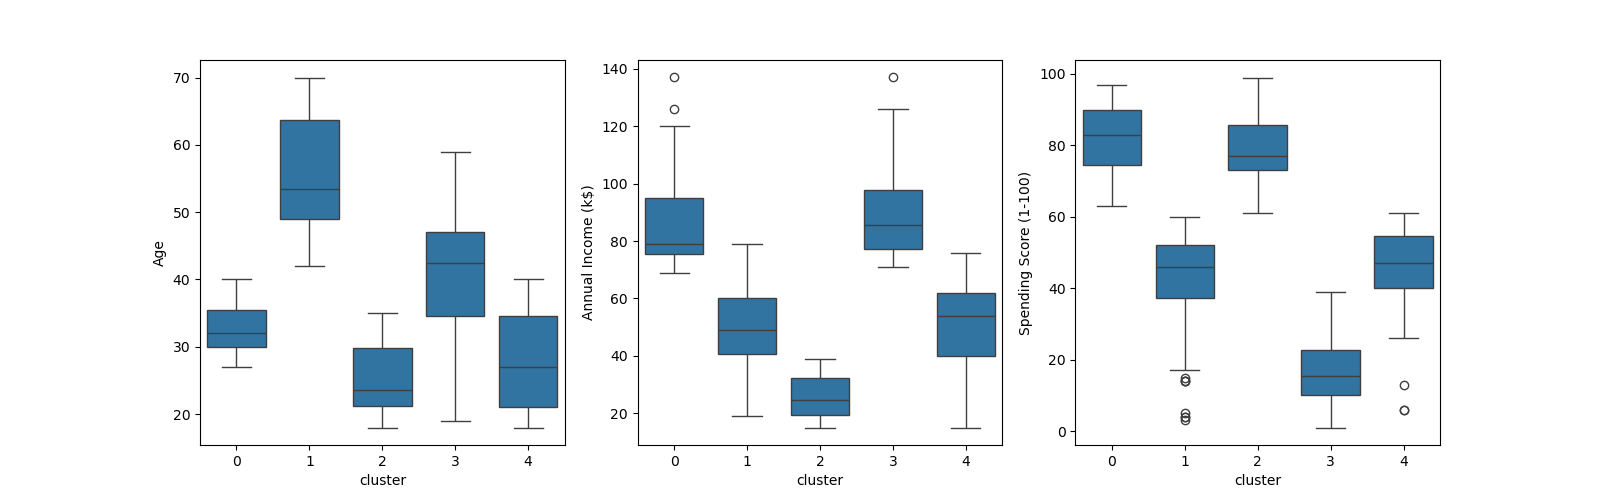

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

for ax, col in zip(axs, df_clustered.select_dtypes("number")):
    sns.boxplot(data=df_clustered, x="cluster", y=col, ax=ax)

plt.show()

- Cluster 0 - pontuação de gastos alta, renda alta, idade jovem
- Cluster 1 - pontuação de gastos moderada, renda moderada, idade alta
- Cluster 2 - pontuação de gastos alta, renda baixa, idade jovem
- Cluster 3 - pontuação de gastos baixa, renda alta, idade moderada
- Cluster 4 - pontuação de gastos moderada, renda moderada, idade jovem

Transformando os pontos acima em uma tabela

| Pontuação de Gastos | Renda | Idade | Cluster |
|---------------------|-------|-------|---------|
| Alta                | Alta  | Jovem | 0       |
| Moderada            | Moderada | Alta | 1       |
| Alta                | Baixa | Jovem | 2       |
| Baixa               | Alta  | Moderada | 3       |
| Moderada            | Moderada | Jovem | 4       |


In [13]:
df_clustered["cluster"].value_counts().sort_index()

cluster
0    39
1    58
2    22
3    34
4    47
Name: count, dtype: int64

In [14]:
df_clustered.groupby(["cluster", "Gender"]).size()

cluster  Gender
0        Female    21
         Male      18
1        Female    33
         Male      25
2        Female    13
         Male       9
3        Female    14
         Male      20
4        Female    31
         Male      16
dtype: int64

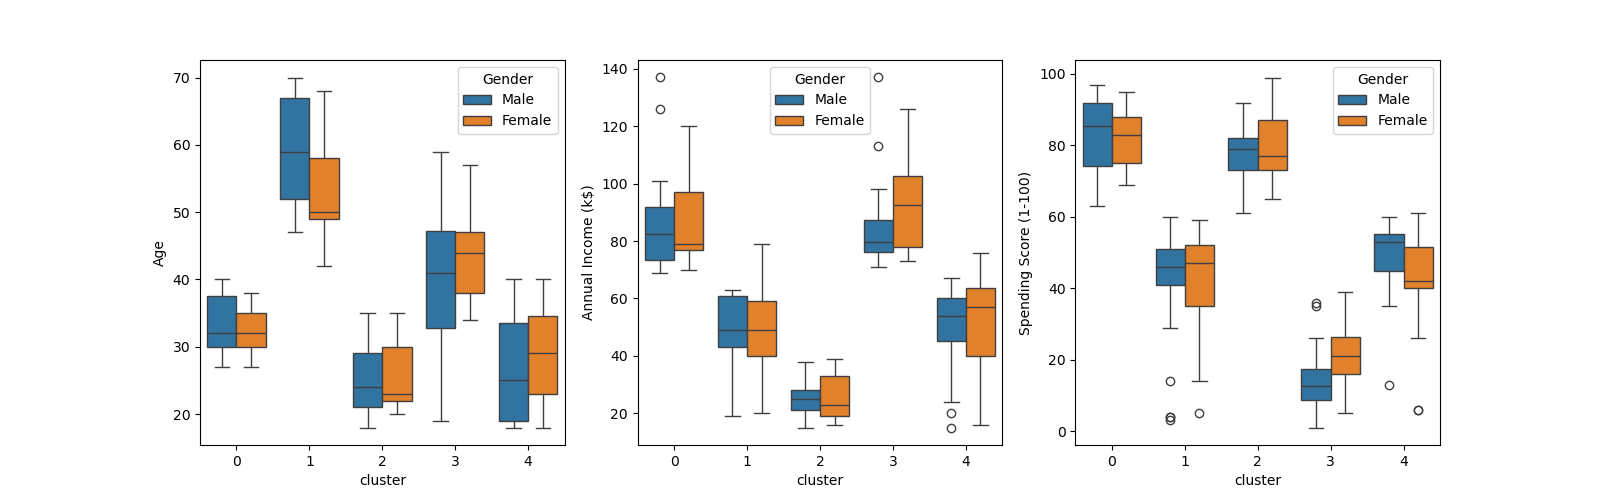

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

for ax, col in zip(axs, df_clustered.select_dtypes("number")):
    sns.boxplot(data=df_clustered, x="cluster", y=col, ax=ax, hue="Gender")

plt.show()

### Análise dos Clusters por Gênero
A figura acima apresenta boxplots das variáveis Age, Annual Income e Spending Score, segmentados por cluster e gênero, permitindo analisar diferenças internas dentro de cada grupo identificado pelo K-Means.

#### Análise Geral
- Em todos os clusters, homens e mulheres apresentam distribuições semelhantes, indicando que o gênero não foi o principal fator de separação dos grupos.
- As diferenças observadas estão mais relacionadas às variáveis Spending Score e Renda Anual do que ao gênero.
- Isso reforça que a clusterização capturou padrões de comportamento e poder aquisitivo, e não apenas características demográficas.

In [14]:
pipeline["preprocessing"].get_feature_names_out()

array(['standard__Age', 'standard__Annual Income (k$)',
       'standard__Spending Score (1-100)', 'onehot__Gender_Female',
       'onehot__Gender_Male'], dtype=object)

In [15]:
pipeline["clustering"].cluster_centers_

array([[-0.44191719,  0.99158305,  1.23950275,  0.53846154,  0.46153846],
       [ 1.19862745, -0.46098141, -0.32703818,  0.56896552,  0.43103448],
       [-0.97439592, -1.32954532,  1.13217788,  0.59090909,  0.40909091],
       [ 0.17329545,  1.06645385, -1.2980103 ,  0.41176471,  0.58823529],
       [-0.78172248, -0.40306917, -0.21591396,  0.65957447,  0.34042553]])

In [16]:
pipeline["clustering"].cluster_centers_[:, :-2]

array([[-0.44191719,  0.99158305,  1.23950275],
       [ 1.19862745, -0.46098141, -0.32703818],
       [-0.97439592, -1.32954532,  1.13217788],
       [ 0.17329545,  1.06645385, -1.2980103 ],
       [-0.78172248, -0.40306917, -0.21591396]])

In [17]:
centroids=pipeline["clustering"].cluster_centers_[:, :-2]
centroids

array([[-0.44191719,  0.99158305,  1.23950275],
       [ 1.19862745, -0.46098141, -0.32703818],
       [-0.97439592, -1.32954532,  1.13217788],
       [ 0.17329545,  1.06645385, -1.2980103 ],
       [-0.78172248, -0.40306917, -0.21591396]])

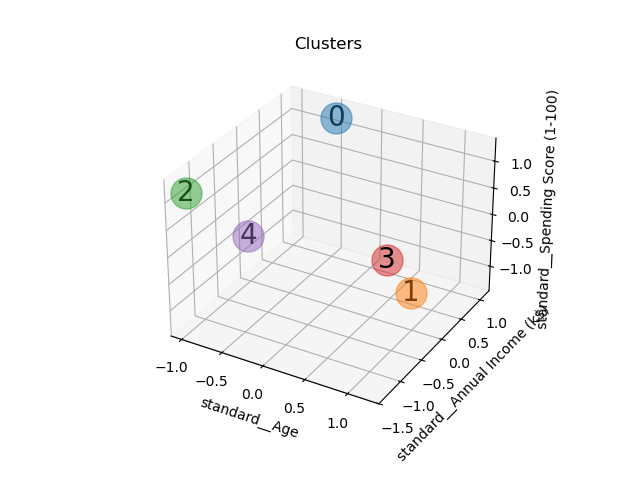

In [18]:
from funcoes_auxiliares import visualizar_clusters

visualizar_clusters(
    dataframe=df_scaled,
    colunas=['standard__Age', 'standard__Annual Income (k$)', 'standard__Spending Score (1-100)'],
    quantidade_cores=5,
    centroids=centroids,
)

### Visualização 3D dos Clusters e Centróides
A figura acima apresenta uma visualização tridimensional dos centróides dos clusters gerados pelo algoritmo K-Means, considerando as variáveis padronizadas.
Cada ponto representa o centróide de um cluster, ou seja, o perfil médio dos clientes pertencentes a esse grupo.

#### Interpretação da Visualização
- Os eixos representam valores padronizados, permitindo comparar variáveis com escalas diferentes.
- A separação espacial entre os centróides indica que os clusters são distintos e bem definidos.
- A posição relativa dos centróides facilita a interpretação dos perfis de clientes em cada cluster.

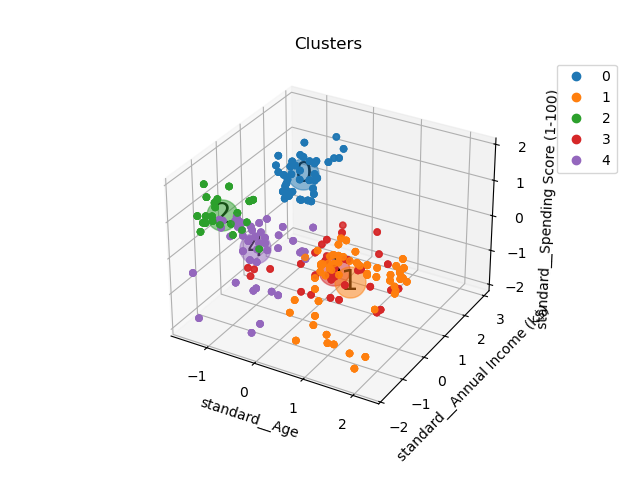

In [19]:
visualizar_clusters(
    dataframe=df_scaled,
    colunas=['standard__Age', 'standard__Annual Income (k$)', 'standard__Spending Score (1-100)'],
    quantidade_cores=5,
    centroids=centroids,
    mostrar_pontos=True,
    coluna_clusters=df_clustered["cluster"]
)

### Análise da Distribuição Espacial
- Os pontos estão bem agrupados ao redor de seus centróides, indicando boa convergência do algoritmo.
- A separação entre os clusters é visualmente clara, reforçando a adequação da escolha de k = 5.